In [4]:
import os
import shutil
import json
import re
import matplotlib.pyplot as plt
import numpy as np

In [5]:
def get_models(root_folder):
    valid_subfolders = []
    for subfolder_name in os.listdir(root_folder):
        subfolder_path = os.path.join(root_folder, subfolder_name)
        if os.path.isdir(subfolder_path):
            output_folder_path = os.path.join(subfolder_path, 'output')
            if os.path.isdir(output_folder_path) and os.listdir(output_folder_path):
                valid_subfolders.append(subfolder_name)
    return valid_subfolders

In [13]:
models = get_models('model_output')
model_name = models[2]
models

['Llama-3-8B-Instruct-Gradient-1048k_5_shot',
 'OpenBioLLM-Llama3-70B_3_shot',
 'Llama-3-70B-Instruct_3_shot']

In [7]:
label_folder = "../../input/lct_p3"
model_folder = f"model_output/{model_name}/output"
ready_folder = f"model_output/{model_name}/ready"
failure_folder = f"model_output/{model_name}/failure"

categories = ['Condition', 'Observation', 'Drug']



#### Filter failure model files

In [8]:
def read_and_process_files(model_name):
    model_folder = f"model_output/{model_name}/output"
    ready_folder = f"model_output/{model_name}/ready"
    failure_folder = f"model_output/{model_name}/failure"
    os.makedirs(ready_folder, exist_ok=True)
    os.makedirs(failure_folder, exist_ok=True)

    def visit(node, category, entities):
        if isinstance(node, dict):
            if category in node:
                entities.extend(node[category])
            for value in node.values():
                visit(value, category, entities)
        elif isinstance(node, list):
            for item in node:
                visit(item, category, entities)

    for filename in os.listdir(model_folder):
        if filename.endswith(".json"):
            file_path = os.path.join(model_folder, filename)
            try:
                with open(file_path, 'r', encoding="utf-8") as file:
                    data = json.load(file)
                entities = []
                visit(data, 'category', entities)
                shutil.copy(file_path, ready_folder)
            except Exception as e:
                shutil.copy(file_path, failure_folder)
                print(f"Error processing file {filename}: {e}")

read_and_process_files(model_name)

Error processing file OpenBioLLM-Llama3-70B_NCT03860025_exc_3_shot.json: Expecting value: line 1 column 1 (char 0)
Error processing file OpenBioLLM-Llama3-70B_NCT03860337_inc_3_shot.json: Expecting value: line 1 column 1 (char 0)
Error processing file OpenBioLLM-Llama3-70B_NCT03861130_inc_3_shot.json: Extra data: line 17 column 1 (char 515)
Error processing file OpenBioLLM-Llama3-70B_NCT03862404_exc_3_shot.json: Extra data: line 58 column 3 (char 1268)
Error processing file OpenBioLLM-Llama3-70B_NCT03863561_exc_3_shot.json: Expecting value: line 1 column 1 (char 0)
Error processing file OpenBioLLM-Llama3-70B_NCT03864705_exc_3_shot.json: Expecting value: line 1 column 1 (char 0)
Error processing file OpenBioLLM-Llama3-70B_NCT03865004_exc_3_shot.json: Expecting value: line 1 column 1 (char 0)
Error processing file OpenBioLLM-Llama3-70B_NCT03865550_exc_3_shot.json: Extra data: line 72 column 3 (char 2102)
Error processing file OpenBioLLM-Llama3-70B_NCT03865589_inc_3_shot.json: Extra data:

In [9]:
def visit(node, category, entities):
    if isinstance(node, dict):
        if category in node:
            entities.extend(node[category])
        for value in node.values():
            visit(value, category, entities)
    elif isinstance(node, list):
        for item in node:
            visit(item, category, entities)

def calculate_metrics(label_data, model_data, metrics):
    for category in categories:
        label_entities = []
        visit(label_data, category, label_entities)
        model_entities = []
        visit(model_data, category, model_entities)

        true_positives = sum(entity in label_entities for entity in model_entities)
        false_positives = sum(entity not in label_entities for entity in model_entities)
        false_negatives = sum(entity not in model_entities for entity in label_entities)

        metrics[category]['true_positives'] += true_positives
        metrics[category]['false_positives'] += false_positives
        metrics[category]['false_negatives'] += false_negatives

def process_files(label_folder, model_folder):
    metrics = {category: {'true_positives': 0, 'false_positives': 0, 'false_negatives': 0} for category in categories}
    for filename in os.listdir(model_folder):
        if filename.endswith('.json'):
            model_path = os.path.join(model_folder, filename)
            match = re.search(r'NCT\d+_(?:exc|inc)', filename)
            if match:
                label_filename = f"{match.group(0)}_p3.json"
                label_path = os.path.join(label_folder, label_filename)

                if os.path.exists(label_path):
                    try:
                        with open(label_path, 'r', encoding='utf-8') as label_file, open(model_path, 'r', encoding='utf-8') as model_file:
                            label_data = json.load(label_file)
                            model_data = json.load(model_file)
                            calculate_metrics(label_data, model_data, metrics)
                    except json.JSONDecodeError as e:
                        print(f"Error decoding JSON file: {model_path}")
                        print(f"Error message: {str(e)}")


    for category in categories:
        true_positives = metrics[category]['true_positives']
        false_positives = metrics[category]['false_positives']
        false_negatives = metrics[category]['false_negatives']

        precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
        recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        accuracy = true_positives / (true_positives + false_positives + false_negatives) if (true_positives + false_positives + false_negatives) > 0 else 0

        metrics[category]['precision'] = precision
        metrics[category]['recall'] = recall
        metrics[category]['f1'] = f1
        metrics[category]['accuracy'] = accuracy

    return metrics

In [10]:
metrics = process_files(label_folder, ready_folder)

print("Metrics:")
for category, scores in metrics.items():
    print(f"{category}:")
    print(f"  Precision: {scores['precision']:.4f}")
    print(f"  Recall: {scores['recall']:.4f}")
    print(f"  F1-score: {scores['f1']:.4f}")
    print(f"  Accuracy: {scores['accuracy']:.4f}")

Metrics:
Condition:
  Precision: 0.4068
  Recall: 0.4604
  F1-score: 0.4320
  Accuracy: 0.2755
Observation:
  Precision: 0.2572
  Recall: 0.3489
  F1-score: 0.2961
  Accuracy: 0.1738
Drug:
  Precision: 0.7760
  Recall: 0.4181
  F1-score: 0.5434
  Accuracy: 0.3731


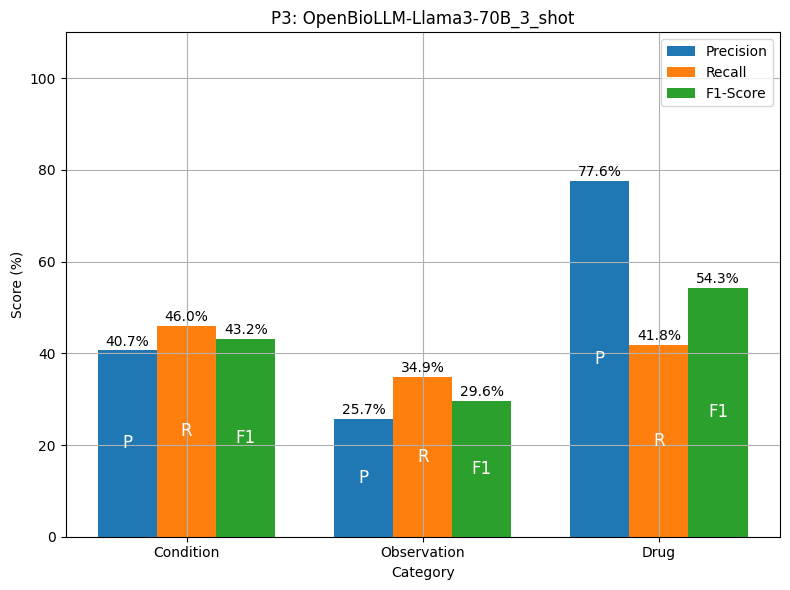

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(categories))
width = 0.25

precision_scores = [metrics[category]['precision'] * 100 for category in categories]
recall_scores = [metrics[category]['recall'] * 100 for category in categories]
f1_scores = [metrics[category]['f1'] * 100 for category in categories]

ax.bar(x - width, precision_scores, width, label='Precision')
ax.bar(x, recall_scores, width, label='Recall')
ax.bar(x + width, f1_scores, width, label='F1-Score')

scores = zip(precision_scores, recall_scores, f1_scores)
for i, (p, r, f1) in enumerate(scores):
    ax.text(i - width, p + 1, f'{p:.1f}%', ha='center', fontsize=10)
    ax.text(i, r + 1, f'{r:.1f}%', ha='center', fontsize=10)
    ax.text(i + width, f1 + 1, f'{f1:.1f}%', ha='center', fontsize=10)
    
    ax.text(i - width, p/2, 'P', ha='center', va='center', fontsize=12, color='white')
    ax.text(i, r/2, 'R', ha='center', va='center', fontsize=12, color='white')
    ax.text(i + width, f1/2, 'F1', ha='center', va='center', fontsize=12, color='white')

ax.set_xlabel('Category')
ax.set_ylabel('Score (%)')
ax.set_title(f'P3: {model_name}')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

ax.set_ylim(0, 110)
ax.grid(True)

plt.tight_layout()
plt.show()